In [1]:
import pandas as pd
import re
from pathlib import Path
from constants import TASK_MODEL_PATH, TOKENIZER_SUFFIXES, MOLNET_DIRECTORY, PROJECT_PATH, DESCRIPTORS, PLOT_PATH, TASK_PATH
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler
import matplotlib
import ast
import json
import re
from statistics import mean, stdev
from copy import copy
from typing import Dict
from glob import glob
from pathlib import Path
from utils import parse_tokenizer, compute_zscore
cm = 1/2.54  # centimeters in inches

colours = reversed(['#56B4E9', '#0072B2', '#E69F00', '#D55E00'])
#colours = reversed(['#332288', '#117733', '#44AA99', '#88CCEE', '#7bafde', '#1965B0', '#AA4499', '#882255'])
matplotlib.rcParams['axes.prop_cycle'] = cycler('color', colours)
pd.set_option('display.max_rows', 500)

/home/jgut/miniconda3/envs/SMILES_OR_SELFIES/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/home/jgut/miniconda3/envs/SMILES_OR_SELFIES/lib/python3.10/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'pytorch_lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'


In [2]:
def clean_string(string:str):
    string = re.sub(r"\'param\_.*\)\,\'params\'", "'params'",string)
    string = string.replace("array([", "[").replace("])", "]")
    string = re.sub(r"\],\s*dtype=.*\),", "],",string)
    return string

def reading_dict(path:Path):
    with open(path, 'r') as f:
        lines = f.readlines()
    #skip first line with estimator name
    return lines[0].strip(), ast.literal_eval(clean_string("".join([line.strip() for line in lines[1:]])))

def get_cells(line:str)->[str]:
    return [cell.strip() for cell in re.split("  ", line) if len(cell)>0]

def parse_dict(dikt:dict):
    best_model_index = dikt['rank_test_score'].index(1)
    best_params = dikt["params"][best_model_index]
    best_scores = []
    for i in range(3):
        best_scores.append(abs(float(dikt[f"split{i}_test_score"][best_model_index])))
    return best_params, mean(best_scores), stdev(best_scores)

def get_report(path:Path):
    estimator, dikt = reading_dict(path)
    best_params, mean_best_scores, std_best_scores = parse_dict(dikt)
    return {"estimator": estimator, "best_params":best_params, "best_scores": mean_best_scores, "std": std_best_scores,}

def parse_tokenizer(tokenizer_string:str):
    """Parse tokenizer string

    Args:
        tokenizer_string (str): tokenizer string to parse

    Returns:
        Dict[str, str]: dictionary with tokenizer settings
    """
    tokenizer_parts = tokenizer_string.split("_")
    output = {
        "embedding": tokenizer_parts[0],
        "tokenizer": tokenizer_parts[1],
        "dataset": tokenizer_parts[2],
    }
    return output

In [3]:
cols = ["embedding","tokenizer","dataset","architecture"]
classification_scores = []
regression_scores = []
TASK_MODEL_PATH = Path("/scratch/jgut/SoS_models/")
for tokenizer_suffix in TOKENIZER_SUFFIXES:
    for task in ["lipo","clintox"]:
        for model in ["bart", "roberta"]:
            task_tokenizer_path = TASK_MODEL_PATH/task/(tokenizer_suffix+"_"+model)
            print(task_tokenizer_path)
            if task_tokenizer_path.exists():
                for hyperparameter_path in glob(str(task_tokenizer_path) + "/*", recursive=True):
                    scores_path = hyperparameter_path+"/scores.csv"
                    if not Path(scores_path).is_file() or not "seed" in str(scores_path):
                        continue
                    print(scores_path)
                    new_score_df = pd.read_csv(scores_path)
                    if list(new_score_df.dataset)[0] == "isomers":
                        continue
                    if list(new_score_df.task_type)[0] == "classification":
                        classification_scores.append(new_score_df)
                    else:
                        regression_scores.append(new_score_df)
regression_scores = pd.concat(regression_scores, axis = 0, sort = False)
classification_scores = pd.concat(classification_scores, axis = 0, sort = False)
regression_score_columns = ["rectified_mean_squared_error"]
regression_pivot = regression_scores.pivot_table(values=regression_score_columns, index=["embedding","tokenizer","dataset","architecture", "seed"],columns=["task"])

scaling_stats = {}
for metric in regression_score_columns:
    for task in regression_scores.task.unique():
        regression_pivot[f"z_{metric}_{task}"] = compute_zscore(regression_pivot[metric][task])
        if metric == "rectified_mean_squared_error":
            scaling_stats[task] = (regression_pivot[metric][task].mean(), regression_pivot[metric][task].std())
mean_regression = regression_pivot.groupby(cols).agg("mean")
classification_metrics = ["ROC_AUC"]
classification_pivot = classification_scores.pivot_table(values=classification_metrics, index=["embedding","tokenizer","dataset","architecture", "seed"],columns=["task"])
for metric in classification_metrics:
    for task in classification_scores.task.unique():
        classification_pivot[f"z_{metric}_{task}"] = compute_zscore(classification_pivot[metric][task])
        if metric == "ROC_AUC":
            scaling_stats[task] = (classification_pivot[metric][task].mean(), classification_pivot[metric][task].std())
cols = ["embedding","tokenizer","dataset","architecture"]
mean_classification = classification_pivot.groupby(cols).agg("mean")

/scratch/jgut/SoS_models/lipo/smiles_atom_isomers_bart
/scratch/jgut/SoS_models/lipo/smiles_atom_isomers_bart/5e-05_0.2_seed_0/scores.csv
/scratch/jgut/SoS_models/lipo/smiles_atom_isomers_bart/5e-05_0.2_seed_1/scores.csv
/scratch/jgut/SoS_models/lipo/smiles_atom_isomers_bart/5e-05_0.2_seed_2/scores.csv
/scratch/jgut/SoS_models/lipo/smiles_atom_isomers_bart/5e-05_0.2_seed_3/scores.csv
/scratch/jgut/SoS_models/lipo/smiles_atom_isomers_bart/5e-05_0.2_seed_4/scores.csv
/scratch/jgut/SoS_models/lipo/smiles_atom_isomers_roberta
/scratch/jgut/SoS_models/lipo/smiles_atom_isomers_roberta/5e-06_0.2_seed_0/scores.csv
/scratch/jgut/SoS_models/lipo/smiles_atom_isomers_roberta/5e-06_0.2_seed_1/scores.csv
/scratch/jgut/SoS_models/lipo/smiles_atom_isomers_roberta/5e-06_0.2_seed_2/scores.csv
/scratch/jgut/SoS_models/lipo/smiles_atom_isomers_roberta/5e-06_0.2_seed_3/scores.csv
/scratch/jgut/SoS_models/lipo/smiles_atom_isomers_roberta/5e-06_0.2_seed_4/scores.csv
/scratch/jgut/SoS_models/clintox/smiles_at

/scratch/jgut/SoS_models/lipo/selfies_atom_isomers_bart/5e-05_0.2_seed_4/scores.csv
/scratch/jgut/SoS_models/lipo/selfies_atom_isomers_roberta
/scratch/jgut/SoS_models/lipo/selfies_atom_isomers_roberta/5e-06_0.2_seed_0/scores.csv
/scratch/jgut/SoS_models/lipo/selfies_atom_isomers_roberta/5e-06_0.2_seed_1/scores.csv
/scratch/jgut/SoS_models/lipo/selfies_atom_isomers_roberta/5e-06_0.2_seed_2/scores.csv
/scratch/jgut/SoS_models/lipo/selfies_atom_isomers_roberta/5e-06_0.2_seed_3/scores.csv
/scratch/jgut/SoS_models/lipo/selfies_atom_isomers_roberta/5e-06_0.2_seed_4/scores.csv
/scratch/jgut/SoS_models/clintox/selfies_atom_isomers_bart
/scratch/jgut/SoS_models/clintox/selfies_atom_isomers_bart/5e-05_0.2_seed_0/scores.csv
/scratch/jgut/SoS_models/clintox/selfies_atom_isomers_bart/5e-05_0.2_seed_1/scores.csv
/scratch/jgut/SoS_models/clintox/selfies_atom_isomers_bart/5e-05_0.2_seed_2/scores.csv
/scratch/jgut/SoS_models/clintox/selfies_atom_isomers_bart/5e-05_0.2_seed_3/scores.csv
/scratch/jgut/S

embedding  dataset   architecture
selfies    standard  roberta         0.875652
smiles     standard  roberta         0.725797
selfies    standard  bart            0.607681
smiles     standard  bart            0.730000
Name: clintox, dtype: float64
embedding  dataset   architecture
selfies    standard  roberta         0.689420
smiles     standard  roberta         0.666087
selfies    standard  bart            0.611159
smiles     standard  bart            0.593333
Name: clintox, dtype: float64
embedding  dataset   architecture
selfies    standard  roberta         1.785172
smiles     standard  roberta         0.364180
selfies    standard  bart           -0.755846
smiles     standard  bart            0.404034
Name: z_ROC_AUC_clintox, dtype: float64
embedding  dataset   architecture
selfies    standard  roberta         0.019240
smiles     standard  roberta        -0.202017
selfies    standard  bart           -0.722864
smiles     standard  bart           -0.891899
Name: z_ROC_AUC_clintox, dty

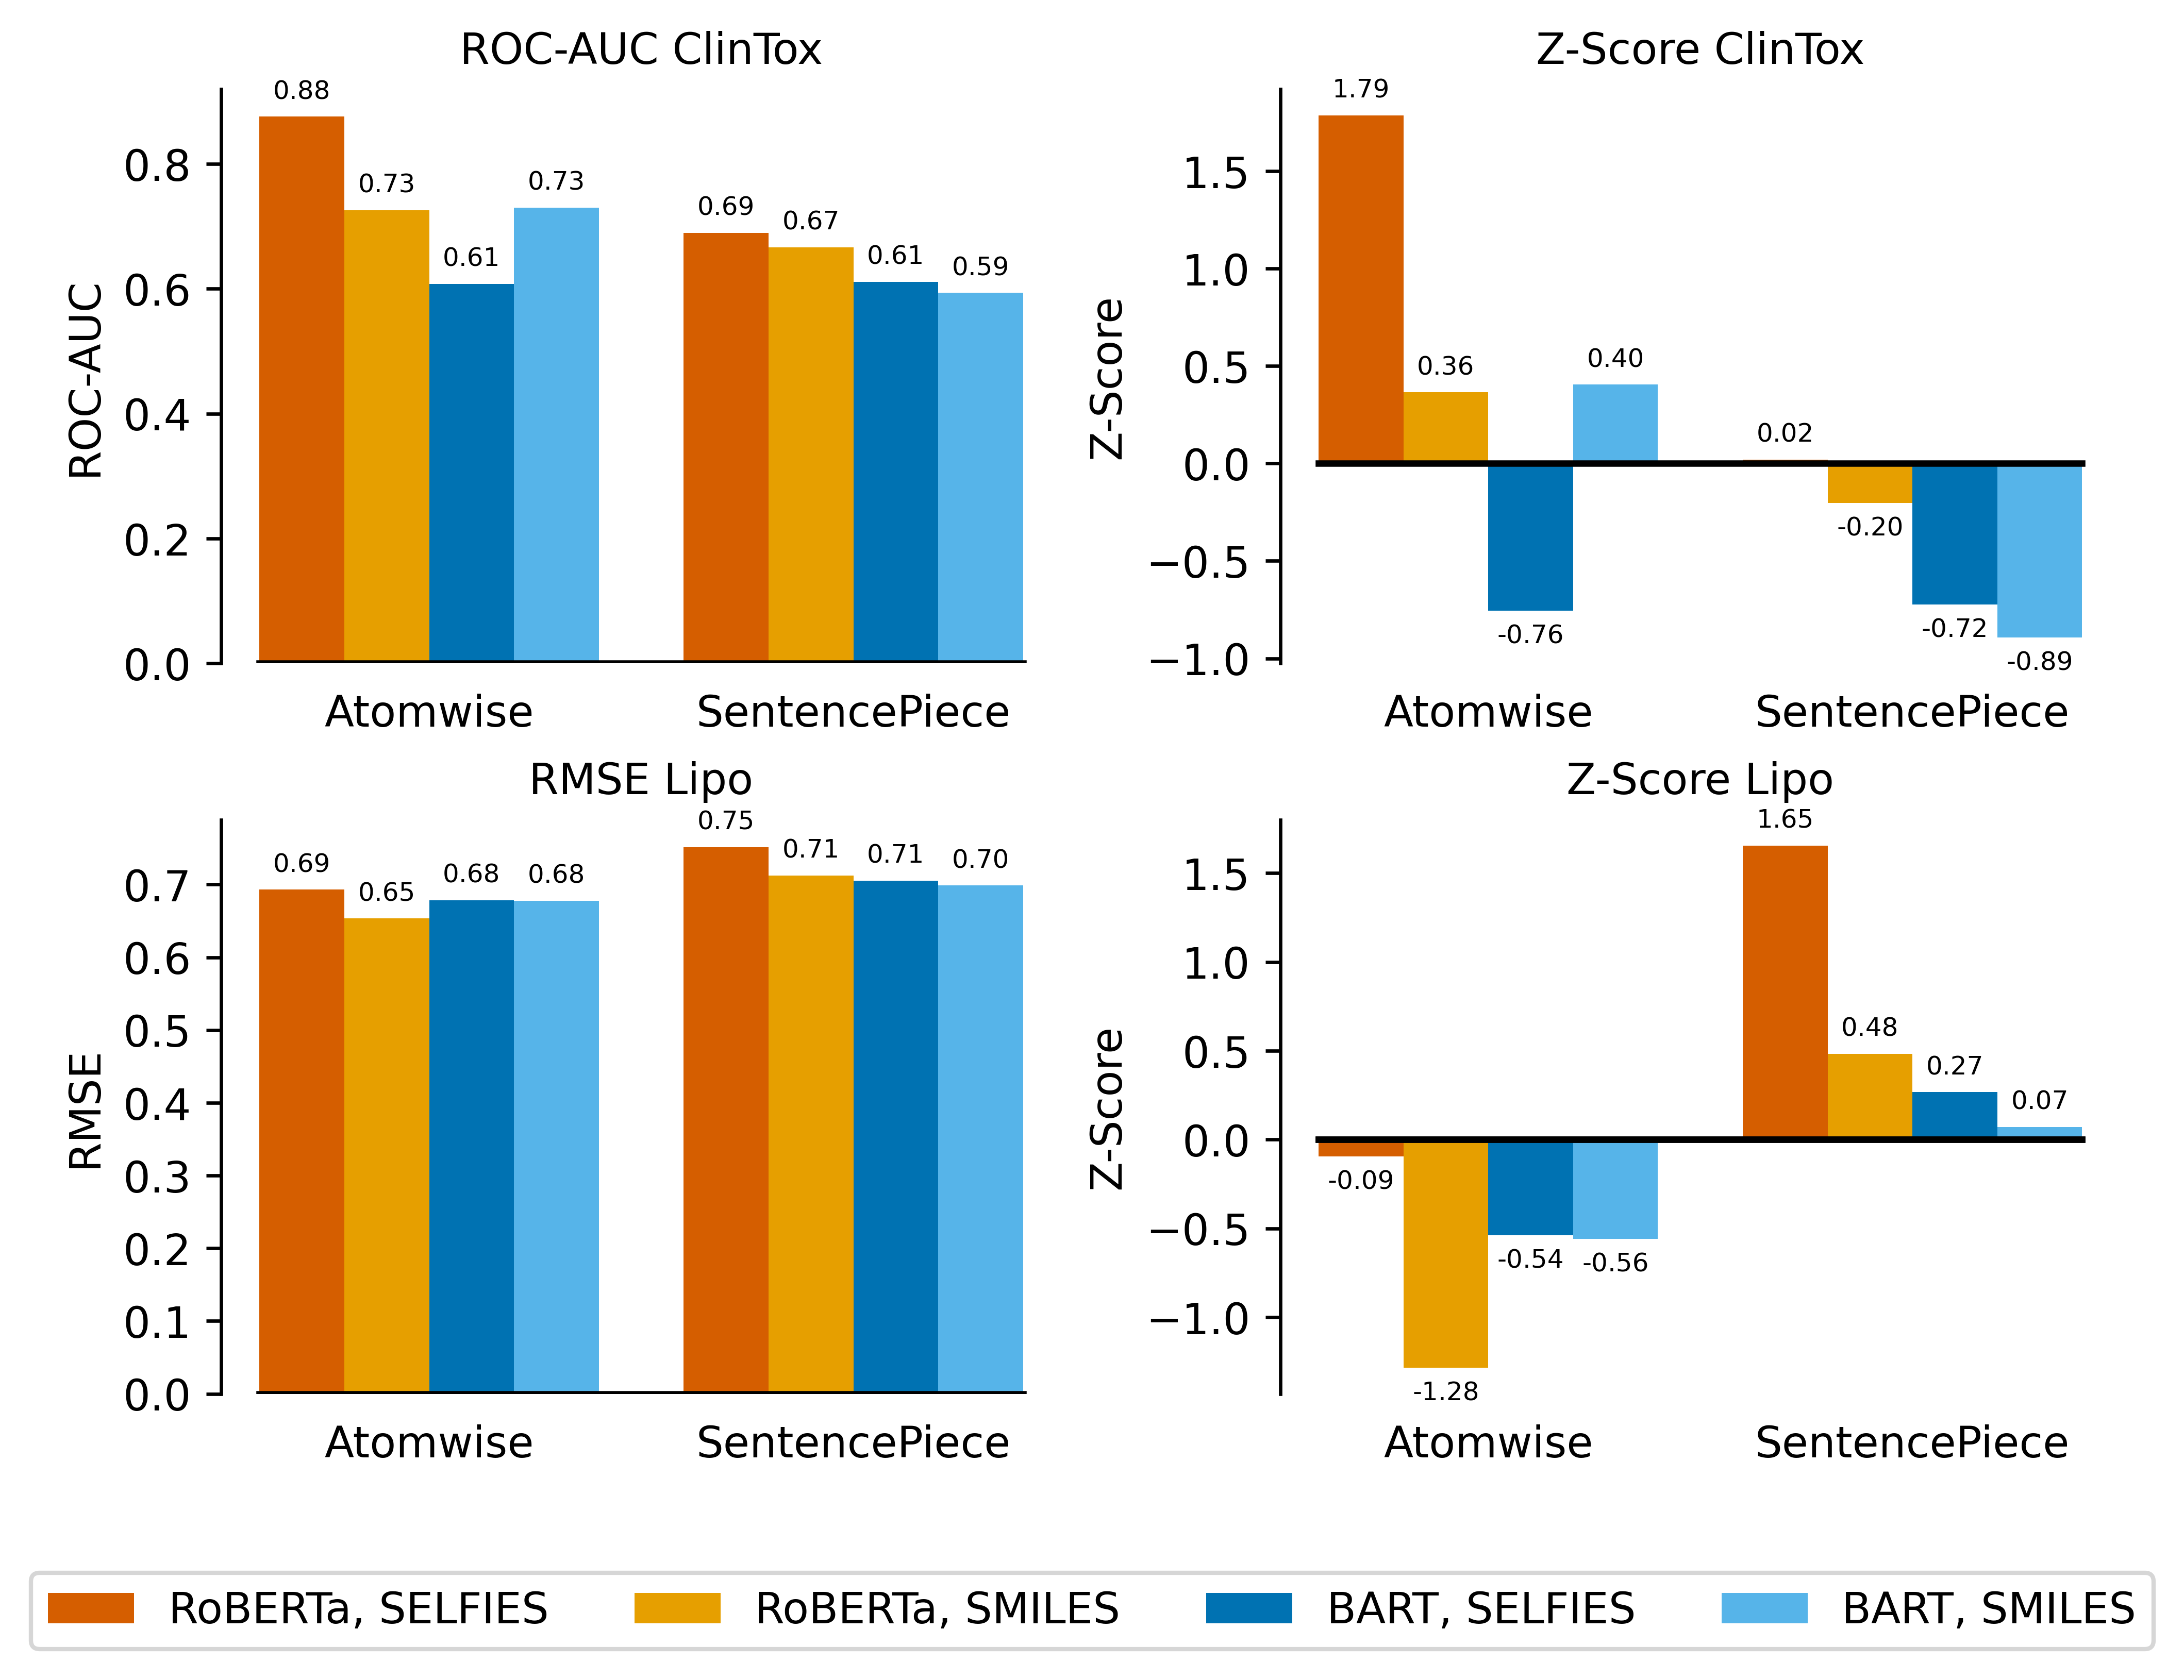

In [4]:
nice_rows = ["RoBERTa, SELFIES","RoBERTa, SMILES", "BART, SELFIES", "BART, SMILES",]
tasks = ["lipo", "clintox"]
data_dict = {}
std_dict = {}

colours = list(reversed(['#56B4E9', '#0072B2', '#E69F00', '#D55E00']))
   
x = np.arange(2)
width = 0.2 # the width of the bars
xs = np.array(range(4))*width
plt.rcParams['font.size'] = 10
fig, axs = plt.subplots(ncols=2, nrows=2, figsize=(17.1*cm, 12*cm), dpi=600, layout='constrained')

cm = 1/2.54
ax = axs[0][0]
ax.plot([-0.1,1.7],[0,0],c="black")

ax.set_ylabel("ROC-AUC")
plt.rcParams['font.size'] = 6
ax.set_xticks([0.3,1.3], ["Atomwise", "SentencePiece"], fontsize=10)    
ax.xaxis.set_ticks_position('none') 

data = mean_classification.loc[:,"atom",:, :].sort_values(by=["architecture",'embedding'], ascending=[False,True])["ROC_AUC"]["clintox"]
print(data)
multiplier = 0
rects = ax.bar(xs, data.values,label=nice_rows, color=colours, width=width)
ax.bar_label(rects, padding=3, fmt='%.2f')
data = mean_classification.loc[:,"trained",:, :].sort_values(by=["architecture",'embedding'], ascending=[False,True])["ROC_AUC"]["clintox"]
print(data)
multiplier = 0
rects = ax.bar(xs+1, data.values,label=nice_rows, color=colours, width=width)
ax.bar_label(rects, padding=3, fmt='%.2f')


ax.spines[['right', 'top', "bottom" ]].set_visible(False)
ax.set_title("ROC-AUC ClinTox", fontsize=10)
ax = axs[0][1]
ax.set_xticks([0.3,1.3], ["Atomwise", "SentencePiece"], fontsize=10)    
ax.xaxis.set_ticks_position('none') 

ax.set_ylabel("Z-Score")
plt.rcParams['font.size'] = 6
ax.plot([-0.1,1.7],[0,0],c="black")


data = mean_classification.loc[:,"atom",:, :].sort_values(by=["architecture",'embedding'], ascending=[False,True])["z_ROC_AUC_clintox"]
print(data)
rects = ax.bar(xs, data.values,label=nice_rows, color=colours, width=width )
ax.bar_label(rects, padding=3, fmt='%.2f')

data = mean_classification.loc[:,"trained",:, :].sort_values(by=["architecture",'embedding'], ascending=[False,True])["z_ROC_AUC_clintox"]
print(data)
rects = ax.bar(xs+1, data.values,label=nice_rows, color=colours, width=width )
ax.bar_label(rects, padding=3, fmt='%.2f')

ax.spines[['right', 'top', "bottom" ]].set_visible(False)
ax.set_title("Z-Score ClinTox", fontsize=10)


ax = axs[1][0]

ax.set_ylabel("RMSE")
plt.rcParams['font.size'] = 6
data = mean_regression.loc[:,"atom",:, :].sort_values(by=["architecture",'embedding'], ascending=[False,True])["rectified_mean_squared_error"]["lipo"]
print(data)
ax.plot([-0.1,1.7],[0,0],c="black")
rects = ax.bar(xs, data.values,label=nice_rows, color=colours, width=width )
ax.bar_label(rects, padding=3, fmt='%.2f')

data = mean_regression.loc[:,"trained",:, :].sort_values(by=["architecture",'embedding'], ascending=[False,True])["rectified_mean_squared_error"]["lipo"]
print(data)
rects = ax.bar(xs+1, data.values,label=nice_rows, color=colours, width=width )
ax.bar_label(rects, padding=3, fmt='%.2f')


ax.spines[['right', 'top', "bottom" ]].set_visible(False)
ax.set_title("RMSE Lipo", fontsize=10)
ax.set_xticks([0.3,1.3], ["Atomwise", "SentencePiece"], fontsize=10)
ax.xaxis.set_ticks_position('none') 

ax = axs[1][1]
ax.set_xticks([0.3,1.3], ["Atomwise", "SentencePiece"], fontsize=10)
ax.xaxis.set_ticks_position('none') 

ax.set_ylabel("Z-Score")
plt.rcParams['font.size'] = 6
data = mean_regression.loc[:,"atom",:, :].sort_values(by=["architecture",'embedding'], ascending=[False,True])["z_rectified_mean_squared_error_lipo"]
print(data)
ax.plot([-0.1,1.7],[0,0],c="black")
rects = ax.bar(xs, data.values,label=nice_rows, color=colours, width=width )
ax.bar_label(rects, padding=3, fmt='%.2f')

data = mean_regression.loc[:,"trained",:, :].sort_values(by=["architecture",'embedding'], ascending=[False,True])["z_rectified_mean_squared_error_lipo"]
print(data)
ax.plot([-0.1,1.7],[0,0],c="black")
rects = ax.bar(xs+1, data.values,label=nice_rows, color=colours, width=width )
ax.bar_label(rects, padding=3, fmt='%.2f')

ax.spines[['right', 'top', "bottom"]].set_visible(False)
ax.set_title("Z-Score Lipo", fontsize=10)


handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.5, -0.05),ncol=4, fontsize=10)
plt.savefig(PLOT_PATH/f'blog_z-score.png', bbox_inches='tight',dpi=600, transparent=True)
plt.show()

In [5]:
entries = []
descriptors = {"mbis_dipole_strength":"MBIS Dipole Strength"}
for descriptor_name in descriptors.keys():
    for encoding in ["SMILES", "SELFIES"]:
        for model in ["BART", "roberta"]:
            report_parent_path = TASK_PATH / descriptor_name / f"{encoding}_{model}" 
            if not report_parent_path.exists():
                continue
            for estimators_file in report_parent_path.glob("*.txt"):
                entry = {"descriptor": descriptor_name, "architecture": model, "encoding":encoding} | get_report(estimators_file) 
                entries.append(entry)
atomic_df = pd.DataFrame(entries)
entries = []
for descriptor_name in ["MolLogP"]:
    for tokenizer_suffix in TOKENIZER_SUFFIXES:
        for model in ["bart", "roberta"]:
            report_parent_path = PROJECT_PATH / f"embeddings_{model}" / descriptor_name / tokenizer_suffix / "reports"
            if not report_parent_path.exists():
                continue
            for estimators_file in report_parent_path.glob("*.txt"):
                entry = {"descriptor": descriptor_name, "architecture": model} | parse_tokenizer(tokenizer_suffix) | get_report(estimators_file) 
                entries.append(entry)
mol_df = pd.DataFrame(entries)
mol_df = mol_df[(mol_df.tokenizer==("atom")) & (mol_df.dataset =="standard")]
second_df = pd.concat([atomic_df,mol_df.rename({"embedding":"encoding"},axis="columns")])
second_df["descriptor"] =second_df["descriptor"].map({"mbis_dipole_strength": "MBIS Dipole Strength", "MolLogP":"MolLogP"})
second_df["architecture"] =second_df["architecture"].map({"BART": "bart", "roberta":"roberta","bart":"bart"})
second_df["encoding"] =second_df["encoding"].map({"SELFIES": "selfies", "SMILES":"smiles", "selfies":"selfies","smiles":"smiles"})
second_df.sort_values(by=["architecture",'encoding'], ascending=[False,True])
full_pivot = pd.pivot_table(second_df, values=["best_scores"],index=["encoding","architecture"],columns=["descriptor","estimator"])

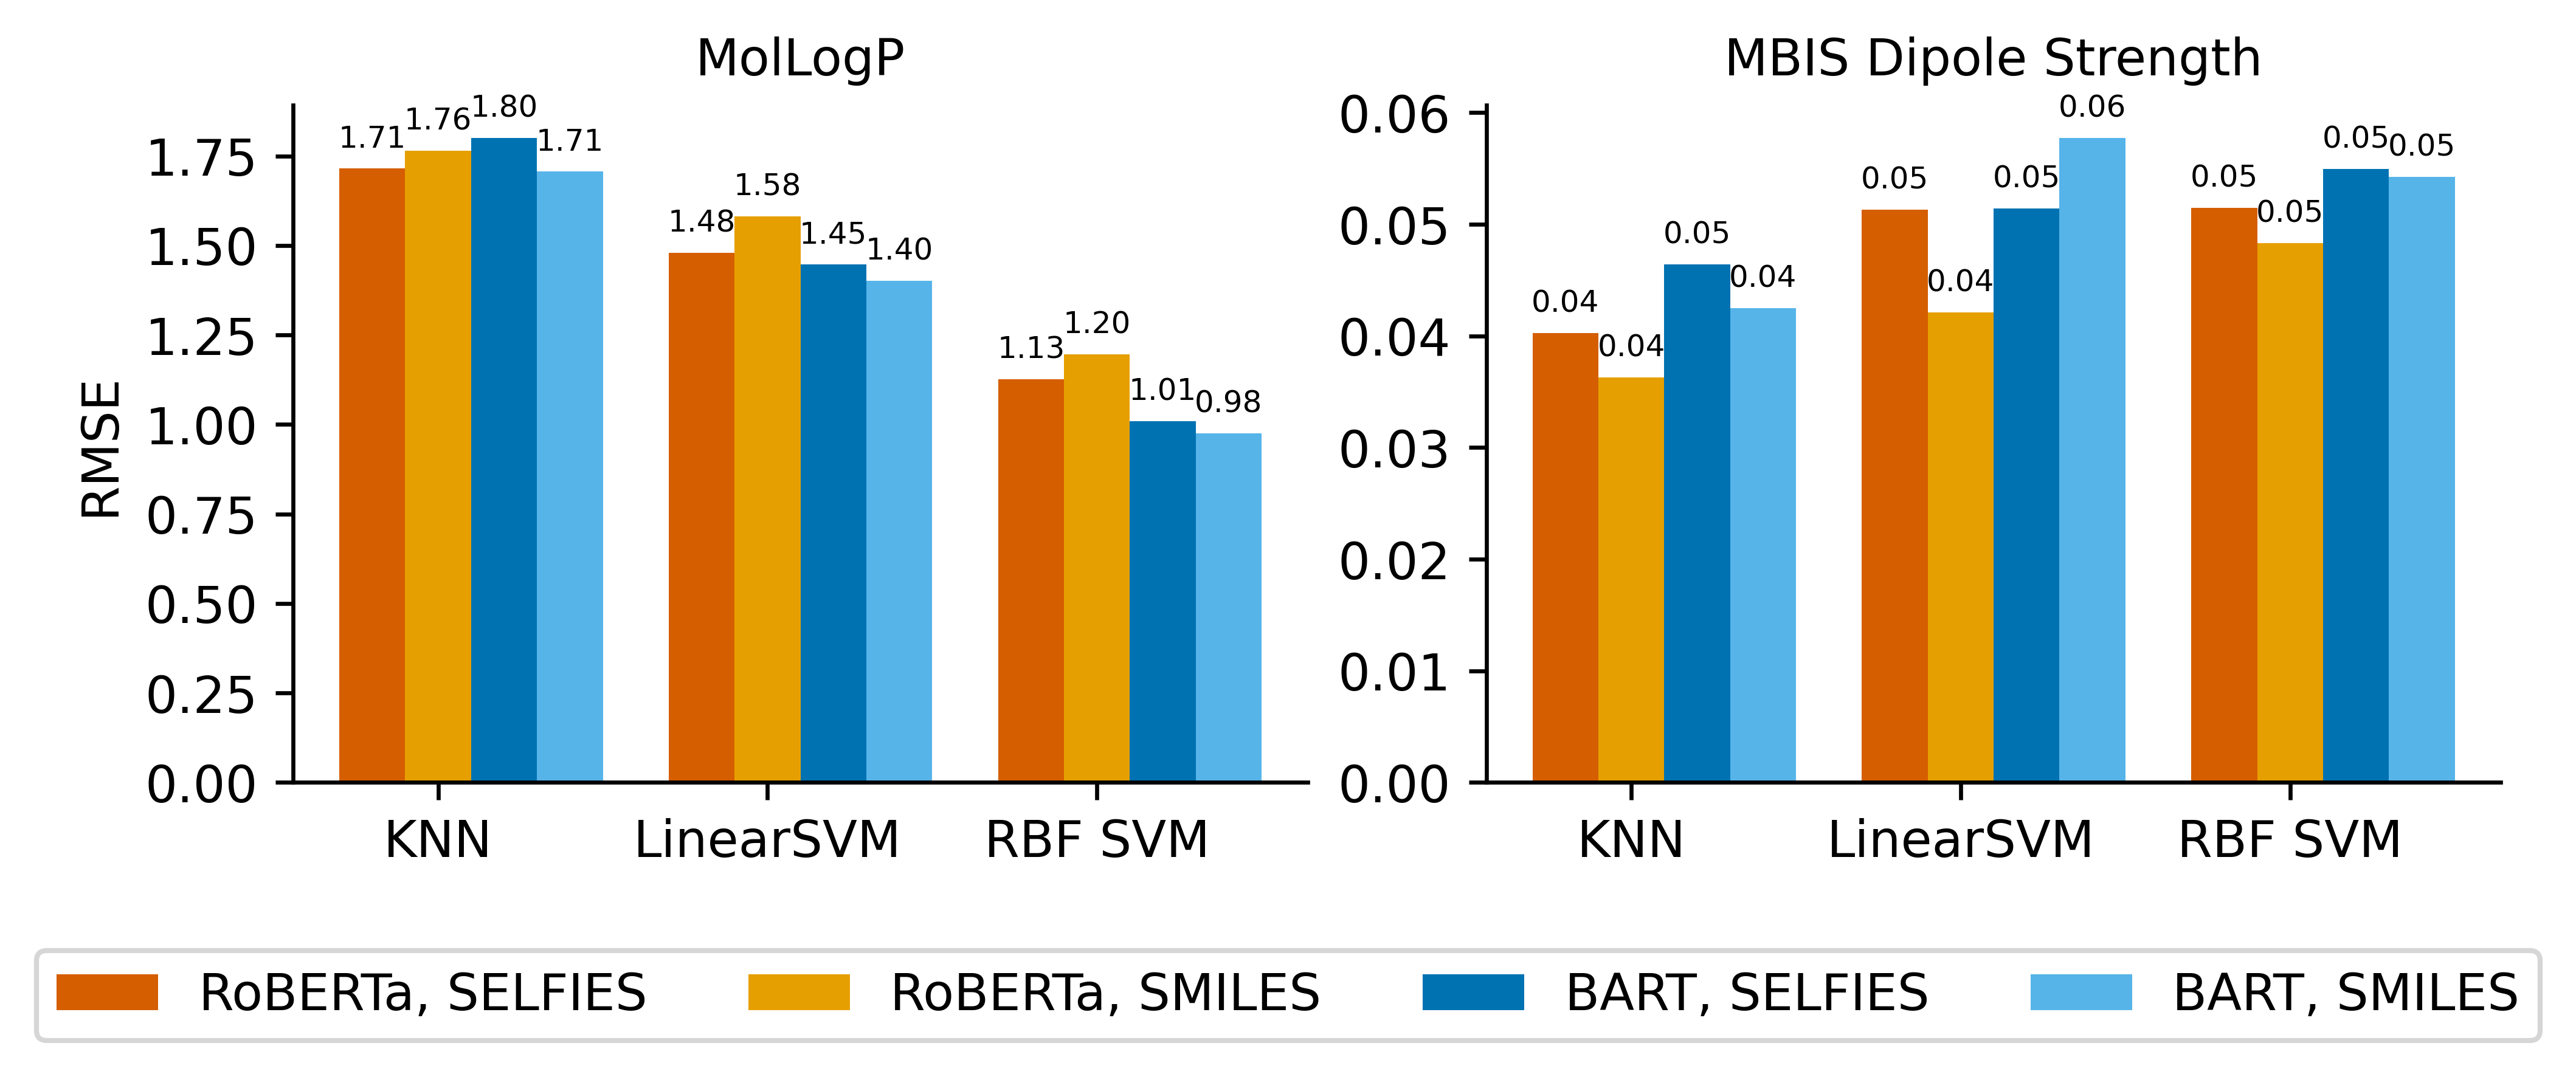

In [6]:
classifiers = ("KNN", "LinearSVM", "RBF SVM")
nice_rows = ["RoBERTa, SELFIES","RoBERTa, SMILES", "BART, SELFIES", "BART, SMILES",]
tasks = ["MolLogP", "MBIS Dipole Strength"]
data_dict = {}
std_dict = {}

for task in tasks:
    data_dict[task] = {nice_rows[it]: vals for it, vals in enumerate(full_pivot["best_scores"][task].sort_values(by=["architecture",'encoding'], ascending=[False,True]).values)}
    
x = np.arange(len(classifiers))  # the label locations
width = 0.2  # the width of the bars
plt.rcParams['font.size'] = 10
fig, axs = plt.subplots(ncols=2, figsize=(17.1*cm, 6*cm), dpi=600, layout='constrained')
axs[0].set_ylabel("RMSE")
for it, task in enumerate(tasks):
    ax = axs[it]
    plt.rcParams['font.size'] = 6
    data = data_dict[task]
    multiplier = 0
    for attribute, measurement in data.items():
        offset = width * multiplier
        rects = ax.bar(x + offset, measurement, width, label=attribute)
        ax.bar_label(rects, padding=3, fmt='%.2f')
        multiplier += 1
    ax.spines[['right', 'top', ]].set_visible(False)
    ax.set_title(task, fontsize=10)
    ax.set_xticks(x + width, classifiers, fontsize=10)     
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
fig.legend(by_label.values(), by_label.keys(), loc='upper center', bbox_to_anchor=(0.5, -0.05),ncol=4, fontsize=10)
plt.savefig(PLOT_PATH/f'blog_atomic_molecular.png', bbox_inches='tight',dpi=600, transparent=True)
plt.show()